## Importing packages and functions


In [1]:
from functions.landcover_loader import *
from functions.modis_loader import *
from functions.lc_filter import *
from functions.plot_functions import *
from functions.smooth_timeseries import *
from functions.get_phenology import *

## Load MODIS

In [2]:
year = "2017"

dc_raw = modis_loader16(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\gis\geodata\bioreservat_rhön.geojson", datetime=f"{year}-01-01/{year}-12-30").sel(time=year).transpose('time', 'latitude', 'longitude')

Searching MODIS catalog for 16 day resolution
Found 48 items (19.96 MB


## Load Landcover

In [3]:
lc = landcover_loader(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\gis\geodata\bioreservat_rhön.geojson", as_single_layer = True)

Searching LC catalog
landcover loaded


## Landcover filter

In [12]:
class_codes = [60]
dc = lc_filter(dc_raw, lc, class_codes = class_codes)

datacube clipped


## Smoothing

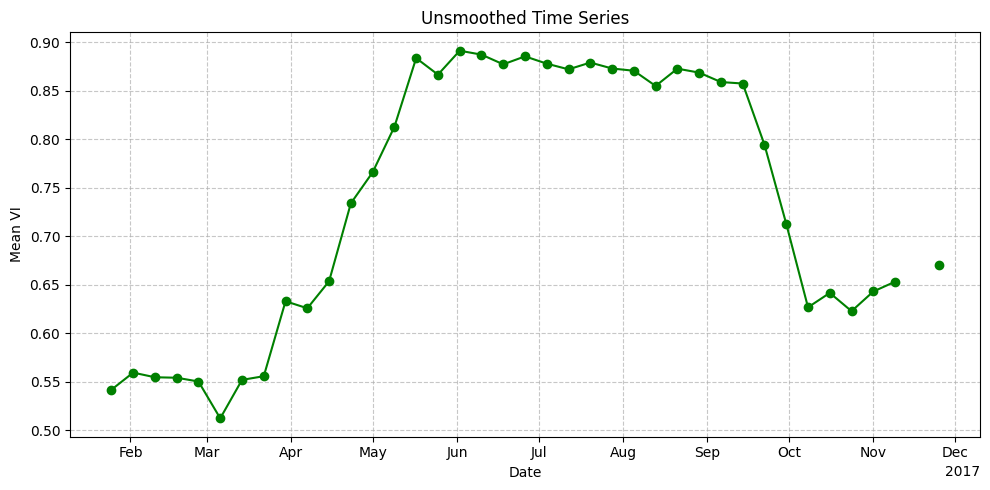

In [13]:
timeplot(dc, title="Unsmoothed Time Series")
dc = smooth_timeseries(dc, window_size=5)

## Time Series Plot

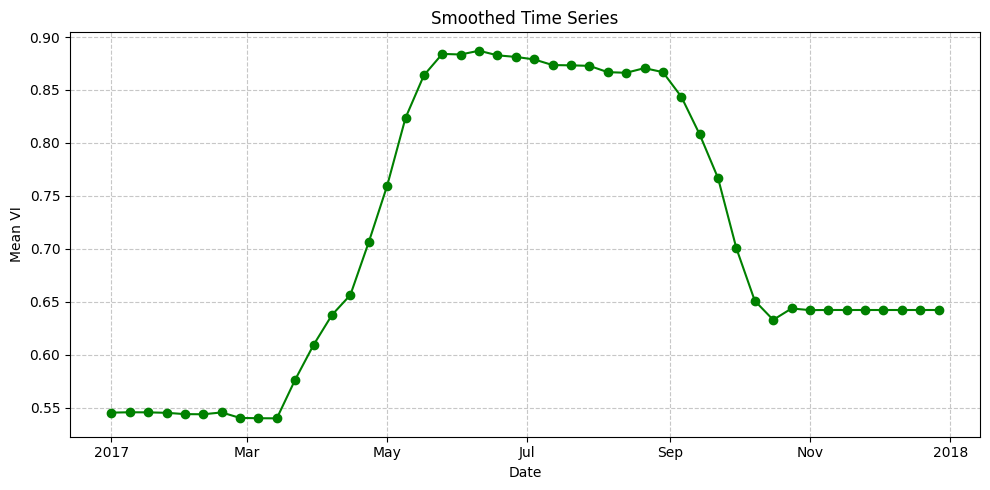

In [14]:
timeplot(dc, title="Smoothed Time Series")

In [11]:
see_individual_timeseries = False

if see_individual_timeseries:
    pixel_timeseries = dc.sel(latitude=50.397636316, longitude= 9.96983439, method='nearest')
    print(pixel_timeseries)

In [8]:
#dc.rio.to_raster(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\results\phenology\tests/daily_modis-sel.tif")

## Phenological stats

In [9]:
phenology = get_phenology(dc.transpose("time", "latitude", "longitude"))
#phenology = lc_filter(phenology, lc, class_codes = class_codes)
#phenology.rio.to_raster(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\results\phenology\tests/test_log_reg3.tif")

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 2.000e+00,
        0.000e+00, 3.000e+00, 4.000e+00, 6.000e+00, 3.000e+00, 6.000e+00,
        4.000e+00, 7.000e+00, 8.000e+00, 3.400e+01, 4.900e+01, 3.400e+01,
        2.700e+01, 2.800e+01, 2.700e+01, 2.900e+01, 2.400e+01, 2.200e+01,
        2.400e+01, 2.000e+01, 2.100e+01, 3.500e+01, 3.600e+01, 7.000e+01,
        4.270e+02, 1.045e+03, 9.710e+02, 9.130e+02, 4.730e+02, 1.870e+02,
        2.800e+01, 2.000e+00, 0.000e+00, 3.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([ 70.65395725,  76.56087811,  82.46779896,  88.37471982,
         94.28164067, 100.18856153, 106.09548238, 112.00240324,
        117.90932409, 123.81624495, 129.7231658 , 135.63008666,
        141.53700751, 147.44392837, 153.35084922, 159.25777008,
        165.16469093, 171.07161179, 176.97853264, 182.8854535 ,
        188.79237435, 194.69929521, 200.60621606, 206.51

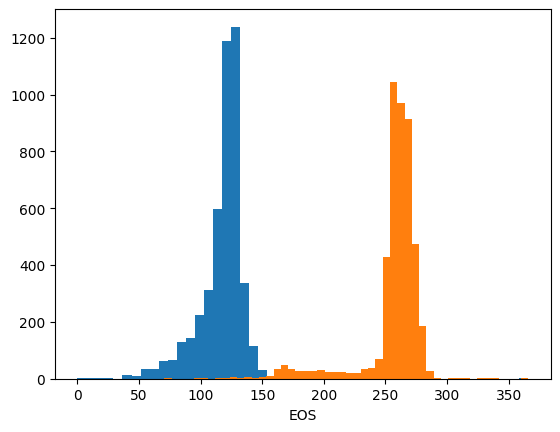

In [10]:
phenology["SOS"].plot.hist(bins=50)
phenology["EOS"].plot.hist(bins=50)